# **IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib

# **Load and show data**

In [2]:
df=pd.read_csv('/content/PhiUSIIL_Phishing_URL_Dataset.csv')

In [3]:
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [4]:
df.shape

(235795, 56)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [6]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [7]:
df.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [8]:
counts = df['label'].value_counts()
print(counts)

label
1    134850
0    100945
Name: count, dtype: int64


# **Data Preprocessing**

In [9]:
df.isnull().sum()

,0
FILENAME,0
URL,0
URLLength,0
Domain,0
DomainLength,0
IsDomainIP,0
TLD,0
URLSimilarityIndex,0
CharContinuationRate,0
TLDLegitimateProb,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
if 'URL' in df.columns:
    url_dupes = df['URL'].duplicated().sum()
    print(f"Number of duplicate URLs: {url_dupes}")
    # Display examples
    df[df['URL'].duplicated(keep=False)].head(10)

Number of duplicate URLs: 425


In [12]:
if 'URL' in df.columns:
    df = df.drop_duplicates(subset=['URL'])
    print(f"Shape after removing duplicate URLs: {df.shape}")

Shape after removing duplicate URLs: (235370, 56)


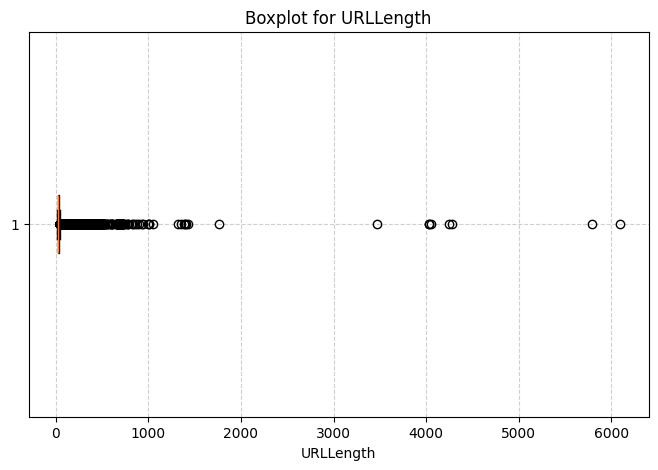

In [13]:
col = "URLLength"
plt.figure(figsize=(8, 5))
plt.boxplot(df[col], vert=False, patch_artist=True)
plt.title(f"Boxplot for {col}")
plt.xlabel(col)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [14]:
col = "URL"

# لو العمود نص → نخليه رقم (طول الرابط)
df["URLLength"] = df[col].astype(str).apply(len)
col = "URLLength"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]

print("Number of outliers:", len(outliers))
print("Min outlier value:", outliers[col].min())
print("Max outlier value:", outliers[col].max())
print("Average normal value:", df[col].mean())


Number of outliers: 21814
Min outlier value: 52
Max outlier value: 6097
Average normal value: 35.33992012575944


In [15]:
df["URLLength"] = df["URL"].astype(str).apply(len)
df = df[df["URLLength"] < 1000]

In [16]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (235351, 56)


# **MODEL**

In [17]:
X = df["URL"].astype(str).tolist()
y = df["label"].tolist()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
max_words = 50000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, char_level=True, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

# Save tokenizer for later use
joblib.dump(tokenizer, "tokenizer.pkl")

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post")


In [20]:
X_train_pad = np.array(X_train_pad)
X_test_pad  = np.array(X_test_pad)
y_train     = np.array(y_train)
y_test      = np.array(y_test)

In [21]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [22]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,449,473 (24.60 MB)

 Trainable params: 6,449,473 (24.60 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = EarlyStopping(monitor="val_loss", patience=3)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/5
2648/2648 ━━━━━━━━━━━━━━━━━━━━ 45s 15ms/step - accuracy: 0.7268 - loss: 0.4660 - val_accuracy: 0.9884 - val_loss: 0.0581
Epoch 2/5
2648/2648 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.9802 - loss: 0.0618 - val_accuracy: 0.9975 - val_loss: 0.0148
Epoch 3/5
2648/2648 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.9976 - loss: 0.0145 - val_accuracy: 0.9977 - val_loss: 0.0154
Epoch 4/5
2648/2648 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.9979 - loss: 0.0137 - val_accuracy: 0.9977 - val_loss: 0.0132
Epoch 5/5
2648/2648 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.9980 - loss: 0.0127 - val_accuracy: 0.9978 - val_loss: 0.0122


In [25]:
loss, acc = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

1471/1471 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9978 - loss: 0.0115
Test Accuracy: 99.78%


# **Save Model**

In [26]:
y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["legitimate", "phishing"]))

1471/1471 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00     20029
    phishing       1.00      1.00      1.00     27042

    accuracy                           1.00     47071
   macro avg       1.00      1.00      1.00     47071
weighted avg       1.00      1.00      1.00     47071



In [ ]:
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix:")
print(cm)

print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Negatives (TN): {TN}")

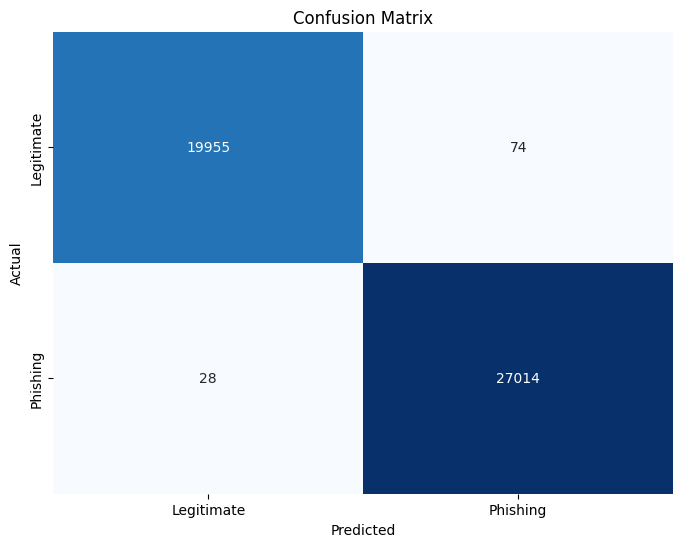

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Legitimate", "Phishing"],
            yticklabels=["Legitimate", "Phishing"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
model.save("lstm_url_model.h5")
print("LSTM Model saved as lstm_url_model.h5")

LSTM Model saved as lstm_url_model.h5


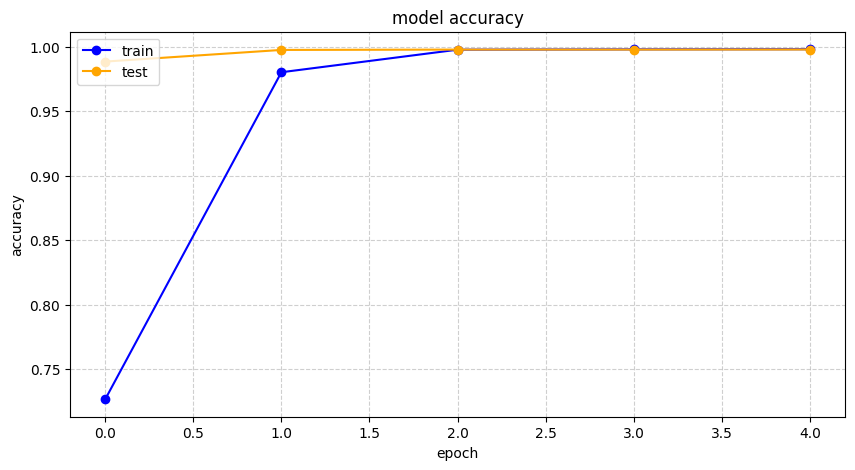

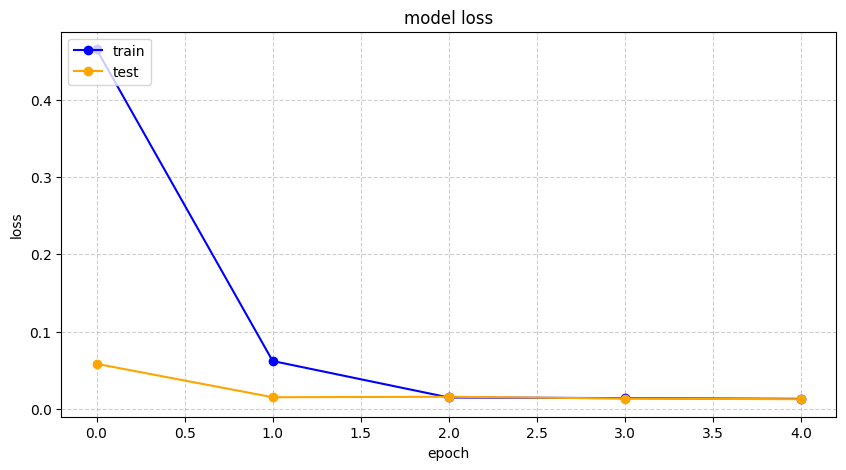

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='train', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='test', color='orange', marker='o')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. رسم بياني للخسارة (Model Loss)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='train', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='test', color='orange', marker='o')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()